# Customer Behavior: Are Promotions Associated with Changes in Purchasing Behavior?

**Business question:** Before any discount is applied, do customers who use a promotion behave differently from customers who don't; do they spend more (`original_amount`) or
buy more items (`basket_size`)?

Promotion assignment was not randomized in this data, so this notebook estimates
associations, not causal effects. 

**Outcomes modeled**
- `original_amount` — pre-discount transaction value ($)
- `basket_size` — number of items purchased

**Approach:** I implement Bayesian regression for each outcome. This includes prior predictive checks to justify
weakly informative priors, posterior estimation of the promotion effect, and posterior predictive checks to validate
each fitted model's conclusions.

## Setup

In [1]:
import logging
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm
import arviz as az
import arviz_plots as azp

logging.getLogger("pymc").setLevel(logging.ERROR)
sns.set_theme(style="white")

DATA_PATH = "../data/processed/promo_analysis_dataset.csv"
PALETTE = ["#FC8EAC", "#8A9098"]
RANDOM_SEED = 42

## Data

I built the dataset in PostgreSQL by querying the `analytics.promo_analysis_dataset` view. Each row in the dataset represents a single transaction, combining transaction records, basket details, product attributes, and timestamps.
The key fields are:

```sql
SELECT
    t.transaction_id,
    t.created_at,
    CASE WHEN t.voucher_id IS NOT NULL THEN 1 ELSE 0 END AS promotion_used,
    CASE WHEN t.user_id   IS NOT NULL THEN 1 ELSE 0 END AS loyalty_member,
    t.original_amount,
    t.discount_applied,
    t.final_amount,
    bs.basket_size,
    bs.distinct_items,
    cs.product_categories,
    cs.category_count
FROM transactions t;
```

Full query located in `sql/modeling/promo_analysis_dataset.sql`.

`voucher_id` and `user_id` are kept for tracking. Missing values in these columns represent non-promoted transactions and guest transactions (no user_id). The binary flags `promotion_used` and `loyalty_member` are converted from those missing values.

In [2]:
df = pd.read_csv(DATA_PATH)

df["created_at"] = df["created_at"].astype("datetime64[ns]")
df[["user_id", "voucher_id"]] = df[["user_id", "voucher_id"]].astype("Int64")

print(f"Rows x Cols: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Guest transactions): {df['user_id'].isna().sum():,}")
print(f"Non-promoted transactions): {df['voucher_id'].isna().sum():,}")

Rows x Cols: (14623691, 17)
Duplicate rows: 0
Guest transactions): 7,310,827
Non-promoted transactions): 14,006,140


**Validation summary:** 14,623,691 transactions, 17 columns, no duplicate rows.
`created_at` converted to datetime, and `user_id`/`voucher_id` converted to nullable integers. 

## Treatment and Customer Composition

In [63]:
comp = df[["promotion_used", "loyalty_member"]].mean().rename({
    "promotion_used": "promoted_transactions_pct",
    "loyalty_member": "member_transactions_pct",
})
print((comp * 100).round(2).astype("str") + "%")
print(f"\nPromoted transactions (count): {(df['promotion_used'] == 1).sum():,}")

pd.crosstab(df["promotion_used"], df["loyalty_member"], normalize="index").mul(100).round(2)

promoted_transactions_pct     4.22%
member_transactions_pct      50.01%
dtype: str

Promoted transactions (count): 617,551


loyalty_member,0,1
promotion_used,,
0,49.69,50.31
1,56.82,43.18


Although promotion usage is highly imbalanced, 4.22% of transactions is approximately 617,551 promoted
transactions, which is plenty for the analysis. Loyalty status is close to a 50/50 split overall, but
guests make up a larger share of promoted transactions (56.8%) than of non-promoted ones (49.7%).
Because of that imbalance, tracking loyalty status as a covariate may be useful, even though the primary model just looks at the unadjusted promotion effect.

## Exploratory Outcome Comparisons

The primary outcomes are explored before fitting the model to understand how transactions differ across promotion groups. These comparisons are descriptive and summarize the observed data only. Because promotions were not randomly assigned, the results should not be interpreted as causal effects. 

In [64]:
def plot_outcome_by_group(df, outcome, ylabel):
    is_discrete = pd.api.types.is_integer_dtype(df[outcome])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.boxplot(
        data=df, x="promotion_used", y=outcome, hue="promotion_used", legend=False,
        linewidth=1.5, fliersize=4, palette=PALETTE, ax=axes[0],
    )
    axes[0].set_title(f"Distribution of {ylabel}", fontsize=12, fontweight="bold", pad=12)
    axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["No", "Yes"])
    axes[0].set_xlabel("Promotion Used", fontsize=11, labelpad=10)
    axes[0].set_ylabel(ylabel, fontsize=11, labelpad=10)

    if is_discrete:
        sns.histplot(
            data=df, x=outcome, hue="promotion_used", discrete=True, multiple="dodge",
            stat="percent", common_norm=False, palette=PALETTE, fill=True, alpha=0.5, ax=axes[1],
        )
    else:
        sns.kdeplot(
            data=df, x=outcome, hue="promotion_used", common_norm=False,
            palette=PALETTE, fill=True, alpha=0.5, ax=axes[1],
        )
    axes[1].set_title(f"Relative {ylabel} Distribution", fontsize=12, fontweight="bold", pad=12)
    axes[1].set_xlabel(ylabel, fontsize=11)

    sns.despine()
    plt.tight_layout()
    plt.show()

In [65]:
df.groupby("promotion_used")["original_amount"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
promotion_used,,,,,,,,
0,14006140.0,33.25,17.06,6.0,19.0,31.0,45.5,90.0
1,617551.0,33.23,17.07,6.0,19.0,31.0,45.5,90.0


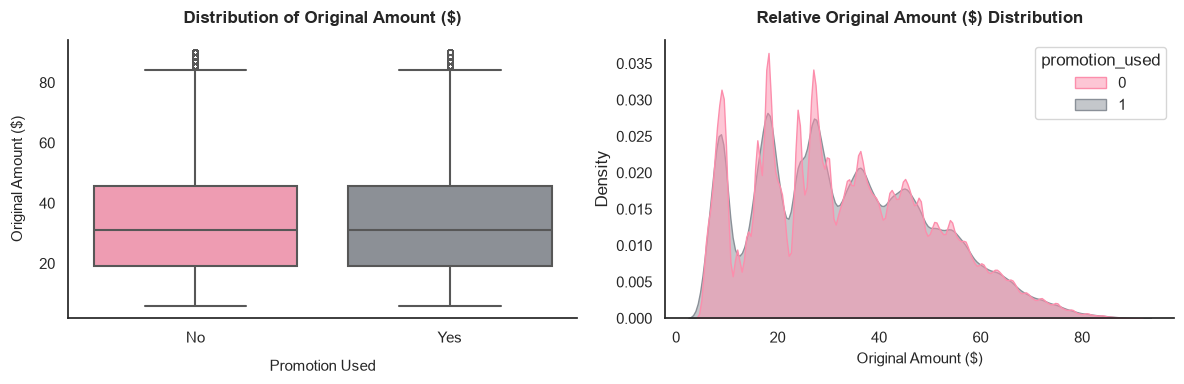

In [66]:
plot_outcome_by_group(df, "original_amount", "Original Amount ($)")

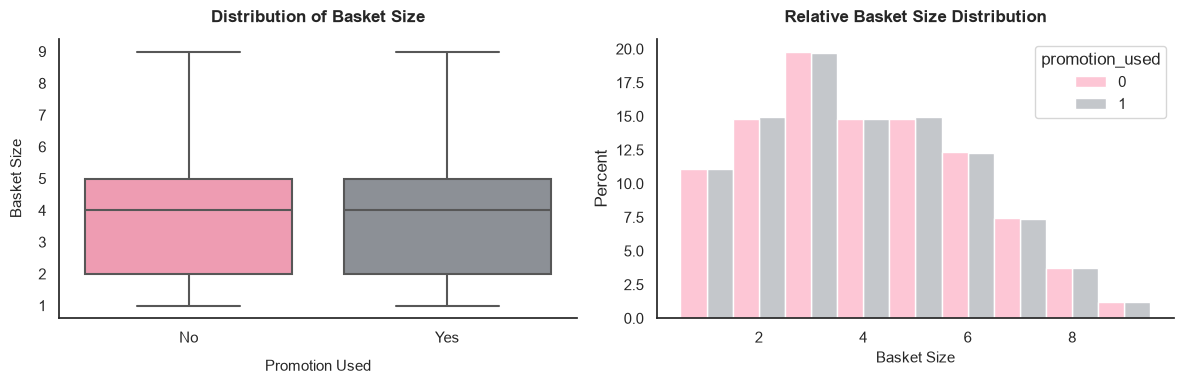

In [67]:
plot_outcome_by_group(df, "basket_size", "Basket Size")

In [68]:
df["analysis_group"] = (
    df["loyalty_member"].map({0: "Guest", 1: "Member"})
    + " | "
    + df["promotion_used"].map({0: "No Promotion", 1: "Promotion"})
)
df.groupby("analysis_group")[["original_amount", "basket_size"]].agg(["mean", "median"]).round(2)

original_amount        basket_size       
                                 mean median        mean median
analysis_group                                                 
Guest | No Promotion            33.25   31.0         4.0    4.0
Guest | Promotion               33.22   31.0         4.0    4.0
Member | No Promotion           33.24   31.0         4.0    4.0
Member | Promotion              33.23   31.0         4.0    4.0

`original_amount` and `basket_size` look nearly identical across
promotion groups, having the same shape, same overlapping distributions, and same descriptives (~$33 and ~4 items average), which holds even after splitting by loyalty status. The Bayesian models will quantify the uncertainty in that there's *no* meaningful difference.

## Bayesian Modeling Framework

I model both outcomes with a three step workflow: 
1) **Prior predictive checks** to choose priors that generate plausible data 
2) **Posterior estimation** to fit the model to observed data 
3) **Posterior predictive checks** to see how well the fitted model reproduces the observed distribution 

I define the modeling workflow once below and reuse it across likelihoods.

For transaction $i$, let $Y_i$ be the outcome and $T_i \in \{0, 1\}$ indicate promotion use ($1$ = promotion). Every model below shares the core linear combination with a baseline intercept $\alpha$ and a promotion effect $\tau$:
$$\eta_i = \alpha + \tau T_i,$$
where $\eta_i$ maps the expected value on the log scale depending on the likelihood. 
- **Lognormal:** $\eta_i$ represents the mean natural logarithm of the outcome
- **Gamma & Truncated Poisson:** $\eta_i$ connects to the rate parameter via an explicit log link function
  
For the Lognormal and Gamma models, $e^\tau$ directly gives the multiplicative promotion-group contrast. For the truncated Poisson, $e^\tau$ describes the underlying rate ratio; the observed mean basket-size difference is calculated from the truncated distribution directly.

All posterior fits use the same random sample of 50,000 transactions from the full 14.6M dataset for
computational efficiency.

In [69]:
df_posterior = df.sample(n=50000, random_state=RANDOM_SEED)
T_i = df_posterior["promotion_used"].to_numpy()

# balanced synthetic treatment vector used only for prior predictive checks,
# so both promotion groups get equal weight when inspecting implied priors
T_prior = np.array([0] * 500 + [1] * 500)

In [70]:
def run_prior_grid(model_builder, param_grid, T_prior, draws=2000, random_seed=RANDOM_SEED, **fixed_kwargs):
    '''Run prior predictive simulation over a grid of hyperparameters.

    model_builder(T, y_obs=None, **params) -> pm.Model
    param_grid: dict of {param_name: [values to try]}
    '''
    results = []
    keys = list(param_grid.keys())
    for combo in product(*param_grid.values()):
        params = dict(zip(keys, combo))
        with model_builder(T_prior, y_obs=None, **fixed_kwargs, **params):
            prior_pred = pm.sample_prior_predictive(draws=draws, random_seed=random_seed)
        results.append({**params, "prior": prior_pred})
    return results


def summarize_prior_predictive(results, outcome_var, low_thresh, high_thresh):
    # Quantiles + tail probabilities for each candidate prior's implied outcome distribution
    summary = []
    for r in results:
        y = r["prior"].prior[outcome_var].values.flatten()
        q = np.quantile(y, [0.01, 0.05, 0.50, 0.95, 0.99])
        row = {k: v for k, v in r.items() if k != "prior"}
        row.update({
            "p1": q[0], "p5": q[1], "median": q[2], "p95": q[3], "p99": q[4],
            f"prob_below_{low_thresh}": np.mean(y < low_thresh),
            f"prob_above_{high_thresh}": np.mean(y > high_thresh),
        })
        summary.append(row)
    return pd.DataFrame(summary).round(3)


def fit_posterior(model_builder, T_i, y_obs, priors, target_accept=0.9):
    ## Build and sample the posterior for a given likelihood
    model = model_builder(T_i, y_obs=y_obs, **priors)
    with model:
        trace = pm.sample(chains=2, cores=2, random_seed=RANDOM_SEED, target_accept=target_accept)
    return model, trace


def summarize_posterior(trace, var_names=("alpha", "tau", "sigma")):
    # Trace plot, parameter summary, and the promotion effect as a percent difference
    var_names = [v for v in var_names if v in trace.posterior]
    azp.plot_trace_dist(trace, var_names=var_names)
    plt.tight_layout()
    plt.show()

    display(az.summary(trace, var_names=var_names, ci_prob=0.94, ci_kind="eti", round_to=3))

    tau_samples = trace.posterior["tau"].values.flatten()
    pct_diff = 100 * (np.exp(tau_samples) - 1)

    print(f"Mean percent difference: {pct_diff.mean():.2f}%")
    print(f"94% credible interval: {np.quantile(pct_diff, [0.03, 0.97]).round(2)}")
    print(f"Probability difference > 0%: {np.mean(pct_diff > 0):.3f}")
    print(f"Probability difference >= 5%: {np.mean(pct_diff >= 5):.4f}")
    return pct_diff


def run_ppc(model, trace, var_name, thin=20, random_seed=RANDOM_SEED):
    # Sample the posterior predictive distribution (every `thin`-th draw, for speed)
    trace_ppc = trace.sel(draw=slice(None, None, thin))
    with model:
        ppc = pm.sample_posterior_predictive(trace_ppc, var_names=[var_name], random_seed=random_seed)
    return ppc


def summarize_continuous_ppc(ppc, var_name, high_thresholds):
    # Posterior predictive mean/quantiles and tail probabilities for a continuous outcome
    y_ppc = ppc.posterior_predictive[var_name].values.flatten()
    print(f"Posterior predictive mean: {y_ppc.mean():.2f}")
    print(f"95th / 99th percentile: {np.quantile(y_ppc, 0.95):.2f}, {np.quantile(y_ppc, 0.99):.2f}")
    for t in high_thresholds:
        print(f"Probability above {t}: {np.mean(y_ppc > t):.4f}")

## Modeling `original_amount`

**Business question:** Does pre-discount transaction value differ between promoted and
non-promoted transactions?

I compare Lognormal and Gamma likelihoods, which both support positive, right-skewed monetary values, but interpret
the outcome, and the promotion effect, differently.

### Lognormal Likelihood

$$Y_i \sim \operatorname{LogNormal}(\mu_i, \sigma), \qquad \mu_i = \alpha + \tau T_i$$

$\alpha$ is the baseline original amount location on the log scale for non-promoted transactions, and $\tau$ is the
promotion-group difference on the log scale. For a Lognormal distribution:

$$\operatorname{Median}(Y_i) = e^{\mu_i}, \qquad E(Y_i) = e^{\mu_i + \sigma^2/2}$$

So for non-promoted transactions ($T_i=0$): $\operatorname{Median}(Y\mid T=0) = e^{\alpha}$ and
$E(Y\mid T=0) = e^{\alpha + \frac{\sigma^2}{2}}$. For promoted transactions ($T_i=1$):
$\operatorname{Median}(Y\mid T=1) = e^{\alpha+\tau}$ and $E(Y\mid T=1) = e^{\alpha+\tau+\frac{\sigma^2}{2}}$.

Because $\sigma$ is shared across both groups, the multiplicative treatment effect is identical
for the mean and the median:

$$\frac{\operatorname{Median}(Y\mid T=1)}{\operatorname{Median}(Y\mid T=0)} = \frac{E(Y\mid T=1)}{E(Y\mid T=0)} = \frac{e^{\alpha+\tau}}{e^{\alpha}} = e^{\tau}$$

so a positive promotion percentage difference $100(e^{\tau} - 1)$ value means higher pre-discount value among promoted transactions. 

In [71]:
def build_lognormal_model(T, y_obs=None, alpha_mu=np.log(33), alpha_sd=0.4, tau_sd=0.1, sigma_sd=0.45):
    with pm.Model() as model:
        alpha = pm.Normal("alpha", mu=alpha_mu, sigma=alpha_sd)
        tau = pm.Normal("tau", mu=0, sigma=tau_sd)
        sigma = pm.HalfNormal("sigma", sigma=sigma_sd)
        mu = alpha + tau * T
        if y_obs is not None:
            pm.LogNormal("original_amount", mu=mu, sigma=sigma, observed=y_obs)
        else:
            pm.LogNormal("original_amount", mu=mu, sigma=sigma, shape=len(T))
    return model

### Lognormal Prior Selection 

$\alpha$ is centered near the observed baseline transaction value: since $e^{3.5}\approx 33$,
$\alpha \sim N(3.5,\ \text{alpha\_sd})$. Choosing an initial `alpha_sd = 0.5`, 95% of prior probability
for $\alpha$ falls within $3.5 \pm 1.96(0.5)$. Exponentiating gives

$$\operatorname{Median}(Y\mid T=0) \in \left[e^{3.5-1.96(0.5)},\ e^{3.5+1.96(0.5)}\right] \approx [\$12.43,\ \$88.23]$$

and, adding in $\sigma^2/2$ gives

$$E(Y\mid T=0) \in \left[e^{3.5-1.96(0.5)+0.31},\ e^{3.5+1.96(0.5)+0.31}\right] \approx [\$14.88,\ \$105.64]$$

$\tau$ is centered at 0 so the model doesn't assume a direction for the promotion effect. With an
initial `tau_sd = 0.2`, ~95% of prior mass falls within $\tau \in [-1.96(0.2), 1.96(0.2)] = [-0.392, 0.392]$,
i.e. promotions could plausibly shift median transaction value anywhere from
$100(e^{-0.392}-1)\approx -32\%$ to $100(e^{0.392}-1)\approx +48\%$ before the model sees any data. $\sigma \sim \text{HalfNormal}(0.5)$ keeps the log-scale spread positive while allowing a wide range of transaction variability.

Thus, I choose initial candidate priors $\alpha \sim N(\log 33, 0.5) \approx N(3.5, 0.5)$, $\tau \sim N(0, 0.2)$, and $\sigma \sim \operatorname{HalfNormal}(0.5)$. which will be evaluated along with nearby alternatives, via prior
predictive simulation. All priors are intentionally weakly informative.

In [72]:
lognormal_broad_grid = run_prior_grid(
    build_lognormal_model,
    param_grid={"alpha_sd": [0.4, 0.5, 0.6], "tau_sd": [0.1, 0.15, 0.2], "sigma_sd": [0.4, 0.5, 0.6]},
    T_prior=T_prior,
)
summarize_prior_predictive(lognormal_broad_grid, "original_amount", low_thresh=6, high_thresh=90)

,alpha_sd,tau_sd,sigma_sd,p1,p5,median,p95,p99,prob_below_6,prob_above_90
0,0.4,0.10,0.4,7.721,13.106,31.953,82.472,139.623,0.005,0.039
1,0.4,0.10,0.5,5.963,11.710,31.946,92.810,179.058,0.010,0.054
2,0.4,0.10,0.6,4.555,10.327,31.931,105.277,234.013,0.017,0.070
3,0.4,0.15,0.4,7.606,12.991,31.958,83.198,141.042,0.005,0.040
4,0.4,0.15,0.5,5.912,11.632,31.938,93.775,180.238,0.010,0.055
5,0.4,0.15,0.6,4.517,10.263,31.925,105.936,235.098,0.017,0.071
6,0.4,0.20,0.4,7.461,12.842,31.958,84.182,143.271,0.005,0.041
7,0.4,0.20,0.5,5.828,11.525,31.944,94.719,182.275,0.011,0.057
8,0.4,0.20,0.6,4.471,10.175,31.930,107.093,236.841,0.018,0.072
9,0.5,0.10,0.4,6.811,11.571,31.725,93.308,160.391,0.007,0.055


`tau_sd` has almost no effect on the implied distribution. The treatment indicator only shifts
half the simulated observations, so it barely moves the combined quantiles. `alpha_sd` has the
largest influence on spread, and `sigma_sd = 0.5` or larger puts too much prior mass into
the tails (95th percentiles above $\$105$, 99th percentiles above $\$200$) relative to the observed $\max \approx \$90$. `sigma_sd = 0.4` keeps the median near $\$32$, a 95th percentile near $\$83$, and a 99th percentile near \$140. This is plausible, while still allowing occasional large transactions.

Since $\tau$'s spread has little effect  on the combined prior predictive summaries, I fix `tau_sd = 0.1` and run a narrower grid over
`alpha_sd` and `sigma_sd` with 0.45 added as an intermediatte value. To check wether a tighter spread gives a better balance between the lower and upper tails, 0.45 for `alpha_sd` and `sigma_sd` is added as an intermediate value.

In [73]:
lognormal_prior_results = run_prior_grid(
    build_lognormal_model,
    param_grid={"alpha_sd": [0.4, 0.45, 0.5], "sigma_sd": [0.4, 0.45, 0.5]},
    T_prior=T_prior,
    tau_sd=0.1,
)
summarize_prior_predictive(lognormal_prior_results, "original_amount", low_thresh=6, high_thresh=90)

,alpha_sd,sigma_sd,p1,p5,median,p95,p99,prob_below_6,prob_above_90
0,0.40,0.40,7.721,13.106,31.953,82.472,139.623,0.005,0.039
1,0.40,0.45,6.795,12.389,31.944,87.435,157.759,0.007,0.046
2,0.40,0.50,5.963,11.710,31.946,92.810,179.058,0.010,0.054
3,0.45,0.40,7.285,12.325,31.839,87.443,148.910,0.006,0.046
4,0.45,0.45,6.455,11.689,31.823,92.342,166.815,0.008,0.054
5,0.45,0.50,5.679,11.053,31.813,97.876,188.656,0.011,0.061
6,0.50,0.40,6.811,11.571,31.725,93.308,160.391,0.007,0.055
7,0.50,0.45,6.094,10.994,31.706,97.930,177.895,0.010,0.063
8,0.50,0.50,5.392,10.424,31.692,103.402,199.507,0.013,0.070


`alpha_sd = 0.4`, `sigma_sd = 0.45` gives the best overall balance, median $\approx \$32$, 95th
percentile $\approx \$88$, 99th $\approx \$158$ — which allows a small proportion of transactions below the
observed $\min \approx \$6$ without generating an unrealistic number of extreme values. 

Final Lognormal priors are
$$\begin{aligned}
    \alpha &\sim N(\log 33,\ 0.4), \\
    \tau &\sim N(0,\ 0.1), \\
    \sigma &\sim \text{HalfNormal}(0.45).
\end{aligned}$$

### Gamma Likelihood

$$Y_i \sim \Gamma(\mu_i, \sigma), \qquad \log(\mu_i) = \alpha + \tau T_i$$

Here $\mu_i$ is directly the expected transaction value, and
$\sigma$ is the standard deviation of transaction values around that mean. For non-promoted and
promoted transactions,

$$E(Y\mid T=0) = e^{\alpha}, \qquad E(Y\mid T=1) = e^{\alpha+\tau}.$$

$100(e^{\tau}-1)$ is the percentage difference in expected pre-discount transaction value between groups. The key difference from the Lognormal
model is Gamma models the conditional mean directly, while Lognormal models the log
scale and needs the $\frac{\sigma^2}{2}$ correction to recover the mean.

$\alpha$ and $\tau$ use the same reasoning as the Lognormal model:
$\alpha \sim N(\log 33, 0.5) \approx N(3.5, 0.5)$, $\tau \sim N(0, 0.1)$. The observed standard
deviation of `original_amount` is $\approx \$17$, so an initial $\sigma \sim \text{HalfNormal}(20)$ allows
variability around that level without being too restrictive.

In [74]:
def build_gamma_model(T, y_obs=None, alpha_mu=np.log(33), alpha_sd=0.45, tau_sd=0.1, sigma_sd=8):
    with pm.Model() as model:
        alpha = pm.Normal("alpha", mu=alpha_mu, sigma=alpha_sd)
        tau = pm.Normal("tau", mu=0, sigma=tau_sd)
        sigma = pm.HalfNormal("sigma", sigma=sigma_sd)
        mu = pm.math.exp(alpha + tau * T)
        if y_obs is not None:
            pm.Gamma("original_amount", mu=mu, sigma=sigma, observed=y_obs)
        else:
            pm.Gamma("original_amount", mu=mu, sigma=sigma, shape=len(T))
    return model

In [75]:
gamma_broad_grid = run_prior_grid(
    build_gamma_model,
    param_grid={"alpha_sd": [0.4, 0.5, 0.6], "tau_sd": [0.1, 0.15, 0.2], "sigma_sd": [15, 20, 25]},
    T_prior=T_prior,
)
summarize_prior_predictive(gamma_broad_grid, "original_amount", low_thresh=6, high_thresh=90)

,alpha_sd,tau_sd,sigma_sd,p1,p5,median,p95,p99,prob_below_6,prob_above_90
0,0.4,0.10,15,0.547,6.468,31.642,73.708,103.967,0.047,0.021
1,0.4,0.10,20,0.039,2.986,30.860,79.291,119.400,0.079,0.032
2,0.4,0.10,25,0.001,1.066,29.858,85.340,137.692,0.112,0.043
3,0.4,0.15,15,0.504,6.338,31.653,74.281,104.896,0.047,0.022
4,0.4,0.15,20,0.033,2.897,30.882,80.003,120.359,0.080,0.033
5,0.4,0.15,25,0.001,1.026,29.900,85.930,138.609,0.113,0.044
6,0.4,0.20,15,0.448,6.186,31.669,75.204,107.061,0.049,0.023
7,0.4,0.20,20,0.026,2.789,30.926,80.961,121.570,0.081,0.034
8,0.4,0.20,25,0.001,0.966,29.947,86.876,139.967,0.115,0.045
9,0.5,0.10,15,0.177,4.849,31.667,83.038,118.566,0.060,0.036


As expected, tau has minimal effect, but several `alpha_sd` and `sigma_sd` settings put 5–14% of prior mass below $\$6$, well beyond what's plausible for a coffee-shop transaction. While the center of the distribution is reasonable, I need to tighten `alpha_sd` and reduce `sigma_sd` to restrict the lower tail and cleanup the overall simulated distribution.

In [76]:
gamma_prior_results = run_prior_grid(
    build_gamma_model,
    param_grid={"alpha_sd": [0.4, 0.45, 0.5], "sigma_sd": [8, 10, 12]},
    T_prior=T_prior,
    tau_sd=0.1,
)
summarize_prior_predictive(gamma_prior_results, "original_amount", low_thresh=6, high_thresh=90)

,alpha_sd,sigma_sd,p1,p5,median,p95,p99,prob_below_6,prob_above_90
0,0.40,8,5.451,12.693,32.233,66.625,87.177,0.012,0.008
1,0.40,10,3.305,10.987,32.148,68.456,91.388,0.020,0.011
2,0.40,12,1.784,9.105,31.991,70.466,96.136,0.030,0.014
3,0.45,8,4.448,11.571,32.185,71.417,95.217,0.015,0.014
4,0.45,10,2.550,9.925,32.118,73.107,98.637,0.024,0.017
5,0.45,12,1.289,8.137,31.980,75.021,103.057,0.035,0.021
6,0.50,8,3.558,10.505,32.116,76.812,104.626,0.019,0.024
7,0.50,10,1.859,8.882,32.081,78.284,107.530,0.030,0.026
8,0.50,12,0.832,7.205,31.946,80.121,111.237,0.041,0.030


The smaller scale produces much more realistic lower-tail values. `alpha_sd = 0.45`,
`sigma_sd = 8` gives a prior predictive median $\approx \$33$, 1st percentile $\approx \$4.5$, 95th $\approx \$72$,
99th $\approx \$96$. This is a reasonable coffee-shop range that still allows occasional small and
high-value purchases. The final Gamma priors are
$$\begin{aligned}
    \alpha &\sim N(\log 33,\ 0.45)\\
    \tau &\sim N(0,\ 0.1) \\
    \sigma &\sim \text{HalfNormal}(8).
\end{aligned}$$

### Posterior: Lognormal

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━ ━━━━━━━━━   1000        0           0.717       7           2124.22 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━ ━━━━━━━━━   1000        0           0.881       3           2086.97 draws/s      0:00:00    0:00:00

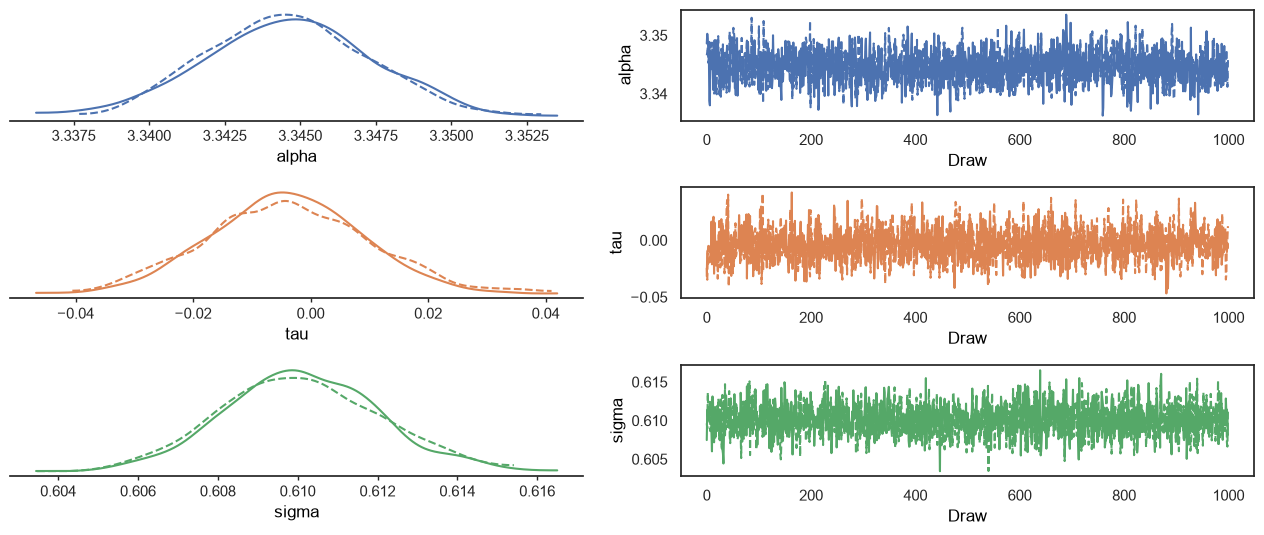

,mean,sd,eti94_lb,eti94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,3.345,0.003,3.340,3.350,1824.335,1560.817,1.000,0.0,0.0
tau,-0.004,0.014,-0.029,0.022,1810.204,1487.769,1.002,0.0,0.0
sigma,0.610,0.002,0.606,0.614,1985.977,1444.166,1.002,0.0,0.0


Mean percent difference: -0.38%
94% credible interval: [-2.87  2.19]
Probability difference > 0%: 0.378
Probability difference >= 5%: 0.0000


In [77]:
y_obs_amount = df_posterior["original_amount"].to_numpy()

lognormal_model, lognormal_trace = fit_posterior(
    build_lognormal_model, T_i, y_obs_amount,
    priors=dict(alpha_mu=np.log(33), alpha_sd=0.4, tau_sd=0.1, sigma_sd=0.45),
)
lognormal_pct_diff = summarize_posterior(lognormal_trace, var_names=("alpha", "tau", "sigma"))

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:00

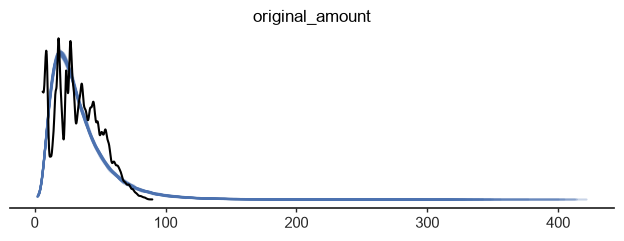

Posterior predictive mean: 34.12
95th / 99th percentile: 77.26, 117.10
Probability above 90: 0.0290
Probability above 200: 0.0007


In [78]:
lognormal_ppc = run_ppc(lognormal_model, lognormal_trace, "original_amount")
azp.plot_ppc_dist(lognormal_ppc, var_names=["original_amount"], num_samples=25)
plt.tight_layout(); plt.show()
summarize_continuous_ppc(lognormal_ppc, "original_amount", high_thresholds=[90, 200])

The Lognormal posterior mean percent difference is about **-0.38%**, with a 94% credible interval of roughly **[-2.87%, 2.19%]** which includes zero, and there is
essentially no posterior probability that promotions raise pre-discount spending by 5% or more.

The posterior predictive check shows the model captures the general right-skewed shape but
overestimates the upper tail, placing about 2.9% of simulated mass above the observed maximum of
$\$90$ and roughly 0.07% above $\$200$. I check this fitting problem against a second likelihood before drawing a conclusion. 

### Posterior: Gamma

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━ ━━━━━━━━━   1000        0           0.549       3           39.07 draws/s        0:00:51    0:00:00   
  ━━━━━━━━━━ ━━━━━━━━━   1000        0           0.745       7           39.95 draws/s        0:00:50    0:00:00

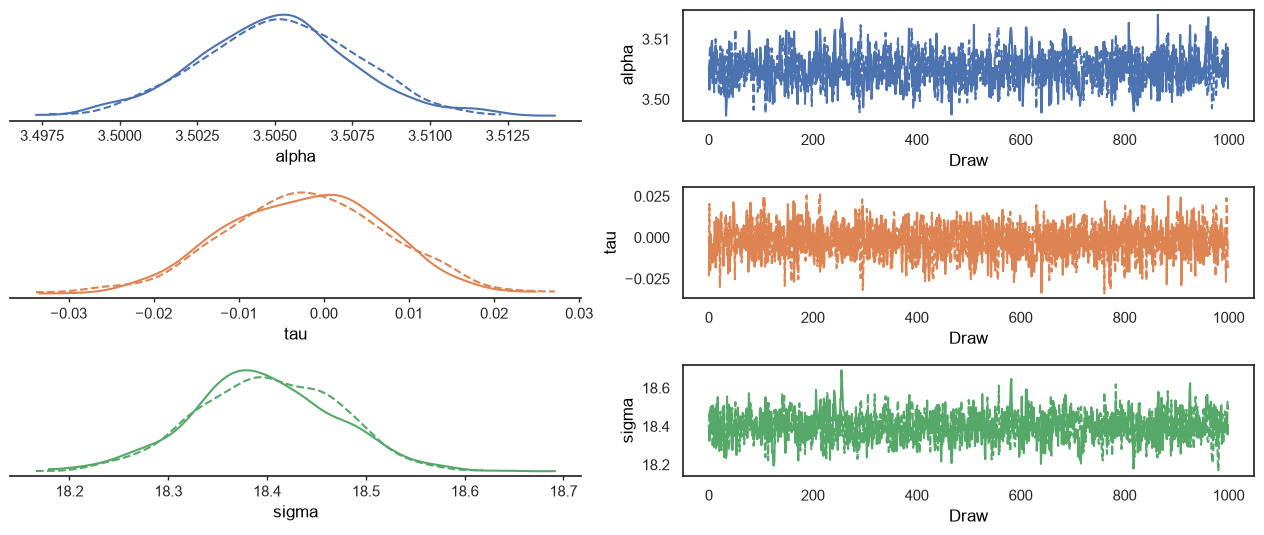

,mean,sd,eti94_lb,eti94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,3.505,0.003,3.500,3.510,865.377,1155.300,1.001,0.000,0.000
tau,-0.002,0.010,-0.021,0.015,1468.391,1414.207,1.000,0.000,0.000
sigma,18.399,0.073,18.261,18.534,949.389,1036.434,1.000,0.002,0.002


Mean percent difference: -0.21%
94% credible interval: [-2.03  1.53]
Probability difference > 0%: 0.418
Probability difference >= 5%: 0.0000


In [79]:
gamma_model, gamma_trace = fit_posterior(
    build_gamma_model, T_i, y_obs_amount,
    priors=dict(alpha_mu=np.log(33), alpha_sd=0.45, tau_sd=0.1, sigma_sd=8),
)
gamma_pct_diff = summarize_posterior(gamma_trace, var_names=("alpha", "tau", "sigma"))

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:00

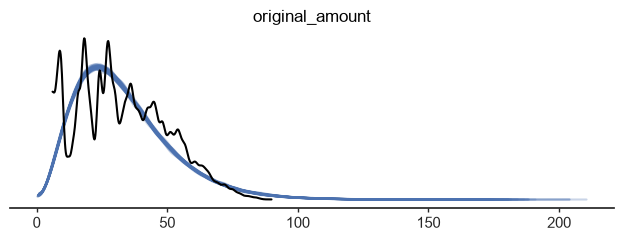

Posterior predictive mean: 33.27
95th / 99th percentile: 68.13, 90.18
Probability above 90: 0.0101
Probability above 150: 0.0001


In [80]:
gamma_ppc = run_ppc(gamma_model, gamma_trace, "original_amount")
azp.plot_ppc_dist(gamma_ppc, var_names=["original_amount"], num_samples=50)
plt.tight_layout(); plt.show()
summarize_continuous_ppc(gamma_ppc, "original_amount", high_thresholds=[90, 150])

The Gamma posterior generates a nearly identical conclusion; posterior mean percent difference of
about **-0.21%**, 94% credible interval **[-2.03%, 1.53%]**, and again no meaningful posterior
probability of a 5% or more increase. But the posterior predictive fit is noticeably better, showing approximately 1.0% of
simulated mass exceeds the observed maximum of $\$90$, and essentially none exceeds $\$150$. The **Gamma likelihood** is preferred because its posterior predictive distribution better matches the observed upper tail. It leads to the same conclusion as the Lognormal model; promotions do not drive a meaningful change in pre-discount spending.

### Why the Distribution Has Repeated Peaks

The observed `original_amount` distribution is multimodal, with
sharp repeated peaks rather than one smooth hump. Before concluding either model is "good enough,"
it's worth checking whether that structure hides a subgroup the treatment model should account for.

In [81]:
peak_amounts = df_posterior["original_amount"].value_counts().head(10).index
peak_transactions = df_posterior[df_posterior["original_amount"].isin(peak_amounts)]

print(f"Correlation between original_amount and basket_size: "
      f"{df_posterior['original_amount'].corr(df_posterior['basket_size']):.2f}\n")

pd.crosstab(
    peak_transactions["original_amount"], peak_transactions["basket_size"], normalize="index"
).round(2)

Correlation between original_amount and basket_size: 0.97



basket_size,1,2,3,4,5,6,7
original_amount,,,,,,,
8.0,1.0,0.0,0.00,0.00,0.00,0.00,0.00
9.0,1.0,0.0,0.00,0.00,0.00,0.00,0.00
16.0,0.0,1.0,0.00,0.00,0.00,0.00,0.00
18.0,0.0,0.7,0.30,0.00,0.00,0.00,0.00
20.0,0.0,0.8,0.20,0.00,0.00,0.00,0.00
24.0,0.0,0.0,0.96,0.04,0.00,0.00,0.00
27.0,0.0,0.0,0.90,0.10,0.00,0.00,0.00
30.0,0.0,0.0,0.57,0.38,0.05,0.00,0.00
36.0,0.0,0.0,0.00,0.62,0.35,0.03,0.00


`original_amount` and `basket_size` correlate at 97%, and the crosstab confirms it directly, revealing
$\$8–\$9$ transactions are entirely 1-item baskets, $\$16–\$20$ are almost entirely 2-item baskets, $\$24–\$27$
are 90%+ 3-item baskets, and so on. Consequently, **repeated peaks are simply repeated menu-price
combinations at each basket size**, not a hidden subgroup, so a mixture model isn't needed here.
`basket_size` is instead modeled directly as its own outcome, below.

### `original_amount` — Answering the Question

Both the Lognormal and Gamma models conclude that pre-discount transaction value is essentially the
same whether or not a promotion was used. The posterior mean difference is negative in both models, the 94% credible interval includes zero, and the probability of even a 5% increase is negligible. The Gamma model (-0.21%, 94% CI [-2.03%, 1.53%]) had the best overall predictive-fit, is
the prefered model for `original_amount` outcome. 

There is **not sufficient evidence to support the claim that customers who use a promotion
spend meaningfully more (or less) before the discount is applied**.

## Modeling `basket_size`

**Business question:** Does the number of items purchased differ between promoted and
non-promoted transactions?

`basket_size` is a bounded count from 1 to 9 items observed which naturally calls for a Poisson likelihood, but a standard Poisson can generate zero-item transactions and basket sizes well above 9 items; implausible for a single coffee-shop transaction and doesn't occur in this dataset. I consider a *zero- and upper-truncated Poisson* count likelihood, restricted to the support our observed counts: $\{1, ..., 9\}$.

In [91]:
basket_mean = df["basket_size"].mean()
basket_var = df["basket_size"].var()
print(f"Mean basket size: {basket_mean:.2f}")
print(f"Variance: {basket_var:.2f}")
print(f"Variance/Mean: {basket_var / basket_mean:.2f}")
print(f"Range: [{df['basket_size'].min()}, {df['basket_size'].max()}]")

Mean basket size: 4.00
Variance: 4.00
Variance/Mean: 1.00
Range: [1, 9]


Mean and variance are both 4.0, giving a 1.0 ratio, consistent with the Poisson assumption for the *center*
of the distribution. The truncation only restricts the tails to make our likelihood match actual coffee-shop orders. 

(*Note*: I also fit a dispersion-flexible truncated Generalized Poisson variant to check if the data violated Poisson's fixed mean-variance relationship. Because its dispersion parameter concentrated essentially at zero, it confirmed that the simpler truncated Poisson distribution is entirely sufficient. I removed that variant from this notebook since it didn't change the results, but the experimental script is available in `notebooks/experiments/truncated_generalized_poisson.ipynb`.)

### Truncated Poisson Likelihood

$$Y_i \sim \operatorname{Poisson}(\mu_i, \text{lower}=1, \text{upper}=9), \qquad \log(\mu_i) = \alpha + \tau T_i$$

$\alpha$ controls the underlying Poisson rate for non-promoted transactions. Centering it at $\log 4$ places that rate near the observed average basket size before accounting for truncation.

$\alpha \sim N(\log 4,\ 0.52)$, which implies a 95% prior interval of

$$\left[4e^{-1.96(0.52)},\ 4e^{1.96(0.52)}\right] \approx [1.44,\ 11.08]$$

This interval accommodates single-item orders while reserving probability mass for larger group orders, allowing uncertainty before seeing the data. For the promotion effect, $\tau \sim N(0, 0.1)$ implies a 95% interval of $\pm 1.96(0.1) = \pm 0.196$, i.e.

$$100(e^{-0.196}-1) \approx -17.8\% \qquad \text{to} \qquad 100(e^{0.196}-1) \approx +21.7\%.$$

Unlike the continuous outcomes, there's no separate dispersion
parameter to specify. For an untruncated Poisson distribution, $\operatorname{Var}(Y_i) = E(Y_i) = \mu_i$. Because the likelihood here is conditioned on basket sizes from 1 through 9, the truncated distribution no longer has mean and variance exactly equal to $\mu_i$.

In [83]:
def build_zt_poisson_model(T, y_obs=None, alpha_mu=np.log(4), alpha_sd=0.25, tau_sd=0.1, lower=1, upper=9):
    with pm.Model() as model:
        alpha = pm.Normal("alpha", mu=alpha_mu, sigma=alpha_sd)
        tau = pm.Normal("tau", mu=0, sigma=tau_sd)
        mu = pm.math.exp(alpha + tau * T)
        base_dist = pm.Poisson.dist(mu=mu)
        pm.Truncated("basket_size", base_dist, lower=lower, upper=upper, observed=y_obs)
    return model

### Prior Selection — Truncated Poisson

A broad grid checks whether the initial `alpha_sd = 0.52`
prior is too loose relative to the observed range of 1–9 items.

In [93]:
poisson_broad_grid = run_prior_grid(
    build_zt_poisson_model,
    param_grid={"alpha_sd": [0.3, 0.45, 0.52], "tau_sd": [0.05, 0.1, 0.15]},
    T_prior=T_prior,
)
summarize_prior_predictive(poisson_broad_grid, "basket_size", low_thresh=2, high_thresh=8)

,alpha_sd,tau_sd,p1,p5,median,p95,p99,prob_below_2,prob_above_8
0,0.30,0.05,1.0,1.0,4.0,8.0,9.0,0.092,0.028
1,0.30,0.10,1.0,1.0,4.0,8.0,9.0,0.093,0.029
2,0.30,0.15,1.0,1.0,4.0,8.0,9.0,0.094,0.030
3,0.45,0.05,1.0,1.0,4.0,8.0,9.0,0.110,0.046
4,0.45,0.10,1.0,1.0,4.0,8.0,9.0,0.110,0.046
5,0.45,0.15,1.0,1.0,4.0,8.0,9.0,0.111,0.047
6,0.52,0.05,1.0,1.0,4.0,9.0,9.0,0.119,0.055
7,0.52,0.10,1.0,1.0,4.0,9.0,9.0,0.119,0.056
8,0.52,0.15,1.0,1.0,4.0,9.0,9.0,0.121,0.056


The wider priors place progressively more probability mass near the upper boundary of 9 items. Reducing `alpha_sd` to 0.3 minimizes this boundary concentration compared to the broader candidates, so I narrow the grid further.

In [94]:
poisson_prior_results = run_prior_grid(
    build_zt_poisson_model,
    param_grid={"alpha_sd": [0.2, 0.25, 0.3]},
    T_prior=T_prior,
    tau_sd=0.1,
)
summarize_prior_predictive(poisson_prior_results, "basket_size", low_thresh=2, high_thresh=8)

,alpha_sd,p1,p5,median,p95,p99,prob_below_2,prob_above_8
0,0.20,1.0,1.0,4.0,8.0,9.0,0.084,0.021
1,0.25,1.0,1.0,4.0,8.0,9.0,0.088,0.024
2,0.30,1.0,1.0,4.0,8.0,9.0,0.093,0.029


`alpha_sd = 0.25` is selected: it stays centered at 4, keeps a 95th percentile of 8, and puts
roughly 2.5% of prior mass at the upper boundary of 9 items, while still leaving about 9% probability for 1-item
baskets. This is more plausible for a coffee-shop order. Final truncated Poisson priors are
$$\begin{aligned} 
    \alpha &\sim N(\log 4,\ 0.25) \\
    \tau &\sim N(0,\ 0.1).
\end{aligned}$$

### Posterior: Truncated Poisson

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━ ━━━━━━━━━   1000        0           0.613       7           17.69 draws/s        0:01:53    0:00:00   
  ━━━━━━━━━━ ━━━━━━━━━   1000        0           0.670       7           17.50 draws/s        0:01:54    0:00:00

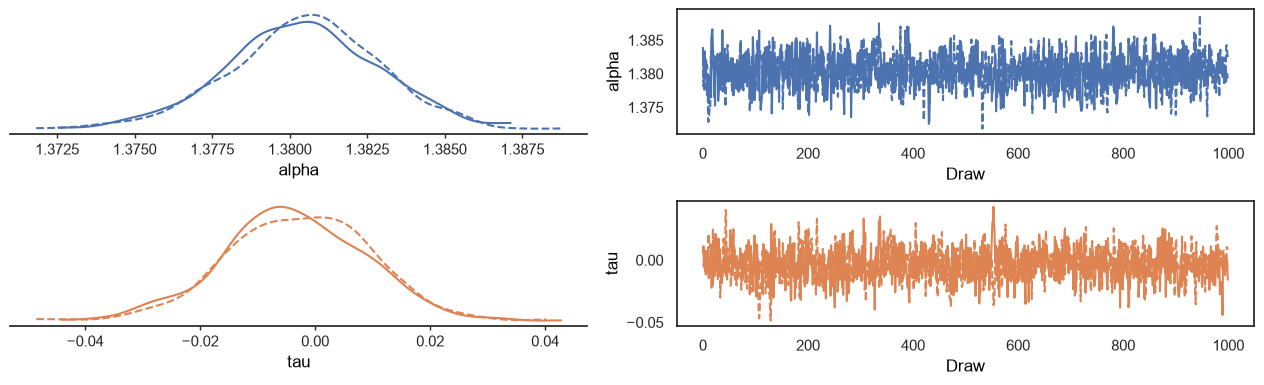

,mean,sd,eti94_lb,eti94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,1.380,0.002,1.376,1.385,1252.440,975.942,1.000,0.0,0.0
tau,-0.003,0.012,-0.028,0.019,944.598,1013.606,1.002,0.0,0.0


Mean percent difference: -0.32%
94% credible interval: [-2.74  1.94]
Probability difference > 0%: 0.400
Probability difference >= 5%: 0.0000


In [95]:
y_obs_basket = df_posterior["basket_size"].to_numpy()

zt_poisson_model, zt_poisson_trace = fit_posterior(
    build_zt_poisson_model, T_i, y_obs_basket,
    priors=dict(alpha_mu=np.log(4), alpha_sd=0.25, tau_sd=0.1),
    target_accept=0.95,
)
basket_pct_diff = summarize_posterior(zt_poisson_trace, var_names=("alpha", "tau"))

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:01

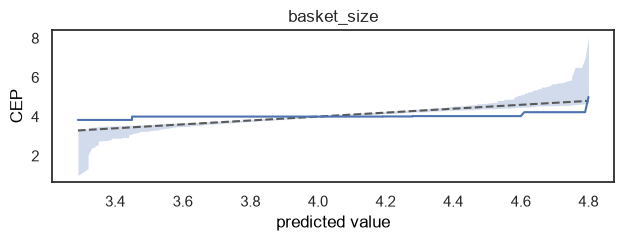

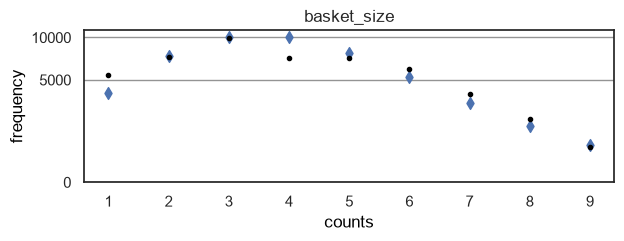

In [96]:
zt_poisson_ppc = run_ppc(zt_poisson_model, zt_poisson_trace, "basket_size")
azp.plot_ppc_pava(zt_poisson_ppc, ci_prob=0.90, var_names=["basket_size"])
plt.tight_layout(); plt.show()
azp.plot_ppc_rootogram(zt_poisson_ppc, var_names=["basket_size"])
plt.tight_layout(); plt.show()

Our promotion percent difference `100(e^\tau - 1)` transform above is a good approximation, but doesn't cleanly describe the basket size posterior since the outcome is
truncated. The *exact* posterior-implied mean basket size for each group is a cleaner way to state
the effect. I compute it directly below:

In [97]:
from scipy.special import gammaln

alpha_samples = zt_poisson_trace.posterior["alpha"].values.flatten()
tau_samples = zt_poisson_trace.posterior["tau"].values.flatten()

mu_control = np.exp(alpha_samples)
mu_promo = np.exp(alpha_samples + tau_samples)


def truncated_poisson_mean(mu, lower=1, upper=9):
    # Posterior mean basket size implied by mu, restricted to the truncated support
    k = np.arange(lower, upper + 1)
    logp = k * np.log(mu[:, None]) - mu[:, None] - gammaln(k + 1)
    logp -= logp.max(axis=1, keepdims=True)
    p = np.exp(logp)
    p /= p.sum(axis=1, keepdims=True)
    return (p * k).sum(axis=1)


mean_control = truncated_poisson_mean(mu_control)
mean_promo = truncated_poisson_mean(mu_promo)
basket_diff_pct = 100 * (mean_promo / mean_control - 1)

print(f"Mean control basket size: {mean_control.mean():.3f}")
print(f"Mean promo basket size: {mean_promo.mean():.3f}")
print(f"Mean percent difference: {basket_diff_pct.mean():.2f}%")
print(f"94% credible interval: {np.quantile(basket_diff_pct, [0.03, 0.97]).round(2)}")
print(f"Probability difference > 0%: {np.mean(basket_diff_pct > 0):.3f}")
print(f"Probability difference >= 5%: {np.mean(basket_diff_pct >= 5):.4f}")

Mean control basket size: 4.001
Mean promo basket size: 3.990
Mean percent difference: -0.27%
94% credible interval: [-2.36  1.66]
Probability difference > 0%: 0.400
Probability difference >= 5%: 0.0000


### `basket_size` — Answering the Question

The truncated Poisson model successfully captures the overall support and center of the basket-size distribution, though the posterior predictive checks reveal minor mismatches at individual basket sizes. Ultimately, these remaining discrepancies do not significantly alter the estimated promotion-group contrast. The
posterior estimate tells us promoted transactions average **3.99 items vs. 4.00 for non-promoted**, a mean
difference of about **-0.27%**, with a 94% credible interval of roughly **[-2.36%, 1.66%]**, surrounding zero. There is essentially no posterior support for a difference of 5% or more in either direction. Therefore, **promotion use is not associated with a meaningfully different basket size.**

## Conclusion

**Business question:** Are promotions associated with changes in customer purchasing behavior
before discounts are applied?

| Outcome | Model | Posterior mean effect | 94% credible interval | P(effect ≥ 5%) |
|---|---|---|---|---|
| `original_amount` | Gamma (log link) | -0.21% | [-2.03%, 1.53%] | ~0.0 |
| `basket_size` | Truncated Poisson (log link) | -0.27% | [-2.36%, 1.66%] | ~0.0 |

Across both outcomes I find **no meaningful difference in purchasing behavior between promoted and non-promoted transactions.** The preferred Gamma model approximates essentially no difference in pre-discount transaction value, and the truncated Poisson gives the same result for basket size. Every credible interval includes zero, and in no model does the posterior assign meaningful probability to even a 5% shift in either direction. In this dataset, promotion use is not associated with a meaningful change in pre-discount purchasing behavior.

**Caveats.** Promotion assignment was observational, not randomized, so these are associations
conditional on the observed data, not causal claims. Loyalty status was associated with promotion usage but was not included in the final unadjusted models. A future extension could estimate promotion-group differences conditional on loyalty status, although the descriptive subgroup comparisons were nearly identical.